In [1]:
import sys

sys.path.append("../")

import scipy
import optuna

import numpy as np
import yfinance as yf

from docplex.mp.model import Model
from optuna.trial import Trial
from qiskit.circuit import ClassicalRegister, ParameterVector, QuantumCircuit, QuantumRegister
from qiskit.primitives import BackendEstimatorV2
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_addon_opt_mapper.converters import OptimizationProblemToQubo
from qiskit_addon_opt_mapper.translators import from_docplex_mp
from qiskit_aer import AerSimulator

from dicke_state_ansatz import DickeStateAnsatz

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
simulator = AerSimulator(method="statevector", device="CPU")
estimator = BackendEstimatorV2(backend=simulator)
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)

In [3]:
tickers = ["MSTR", "KO", "V", "NVDA", "CCJ", "ADBE", "JNJ", "JPM"]
assets_data = yf.download(tickers=tickers, period="1y")

[*********************100%***********************]  8 of 8 completed


In [4]:
assets_close_price = assets_data["Close"]
assets_pct_change = assets_close_price.pct_change().dropna()

In [5]:
covariance_annualized = assets_pct_change.cov()*np.sqrt(252)
returns_annualized = assets_pct_change.mean()*252

In [6]:
q = 0.5
b = 3
return_risk_free = 0.0375
weights_array = np.array([1/b for _ in range(len(tickers))])

## Equality constraint

In [7]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x[{i}]") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@x)+return_risk_free)
model.add_constraint(x.sum() == b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x[0];
dvar bool x[1];
dvar bool x[2];
dvar bool x[3];
dvar bool x[4];
dvar bool x[5];
dvar bool x[6];
dvar bool x[7];

minimize
 0.186768 x[0] - 0.575272 x[1] - 0.221385 x[2] - 0.140881 x[3] - 0.071102 x[4]
 + 0.304747 x[5] - 0.321957 x[6] + 0.003111 x[7] [ 0.000346 x[0]^2
 - 0.000019 x[0]*x[1] - 0.000032 x[0]*x[2] + 0.000058 x[0]*x[3]
 - 0.000004 x[0]*x[4] + 0.000158 x[0]*x[5] + 0.000010 x[0]*x[6]
 + 0.000171 x[0]*x[7] + 0.001042 x[1]^2 - 0.000033 x[1]*x[2]
 + 0.000227 x[1]*x[3] - 0.000075 x[1]*x[4] + 0.000588 x[1]*x[5]
 + 0.000509 x[1]*x[6] + 0.000035 x[1]*x[7] + 0.000099 x[2]^2
 - 0.000006 x[2]*x[3] + 0.000065 x[2]*x[4] - 0.000074 x[2]*x[5]
 - 0.000068 x[2]*x[6] + 0.000030 x[2]*x[7] + 0.000156 x[3]^2
 - 0.000021 x[3]*x[4] + 0.000244 x[3]*x[5] + 0.000155 x[3]*x[6]
 + 0.000120 x[3]*x[7] + 0.000091 x[4]^2 - 0.000109 x[4]*x[5]
 - 0.000096 x[4]*x[6] + 0.00001

In [8]:
quad_model = from_docplex_mp(model=model)
print(quad_model.prettyprint())

Problem name: combinatorial_portfolio_optimization

Minimize
  0.00034582882870326276*x[0]^2 - 1.9111877715248064e-05*x[0]*x[1]
  - 3.2249124001839296e-05*x[0]*x[2] + 5.807884582302285e-05*x[0]*x[3]
  - 4.275150028977837e-06*x[0]*x[4] + 0.00015848173202807187*x[0]*x[5]
  + 9.595449761210255e-06*x[0]*x[6] + 0.00017140370634917304*x[0]*x[7]
  + 0.001042228281842935*x[1]^2 - 3.338451816273136e-05*x[1]*x[2]
  + 0.00022747102040179912*x[1]*x[3] - 7.536010549264493e-05*x[1]*x[4]
  + 0.0005883460630075645*x[1]*x[5] + 0.0005093351050241277*x[1]*x[6]
  + 3.512602288772429e-05*x[1]*x[7] + 9.919768912360015e-05*x[2]^2
  - 5.9044719141154476e-06*x[2]*x[3] + 6.491443653621231e-05*x[2]*x[4]
  - 7.441457185167888e-05*x[2]*x[5] - 6.82011984593182e-05*x[2]*x[6]
  + 2.97301147811718e-05*x[2]*x[7] + 0.0001562757224020732*x[3]^2
  - 2.0673021973191743e-05*x[3]*x[4] + 0.0002444194585181468*x[3]*x[5]
  + 0.00015461870268840874*x[3]*x[6] + 0.00012008195843776206*x[3]*x[7]
  + 9.124734249834468e-05*x[4]^2 - 0

In [9]:
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
print(qubo.prettyprint())

Problem name: 

Minimize
  0.00034582882970326276*x[0]^2 - 1.9111875715248065e-05*x[0]*x[1]
  - 3.22491220018393e-05*x[0]*x[2] + 5.807884782302285e-05*x[0]*x[3]
  - 4.275148028977837e-06*x[0]*x[4] + 0.00015848173402807186*x[0]*x[5]
  + 9.595451761210255e-06*x[0]*x[6] + 0.00017140370834917303*x[0]*x[7]
  + 0.001042228282842935*x[1]^2 - 3.338451616273136e-05*x[1]*x[2]
  + 0.00022747102240179912*x[1]*x[3] - 7.536010349264492e-05*x[1]*x[4]
  + 0.0005883460650075644*x[1]*x[5] + 0.0005093351070241277*x[1]*x[6]
  + 3.512602488772429e-05*x[1]*x[7] + 9.919769012360015e-05*x[2]^2
  - 5.904469914115448e-06*x[2]*x[3] + 6.491443853621232e-05*x[2]*x[4]
  - 7.441456985167887e-05*x[2]*x[5] - 6.82011964593182e-05*x[2]*x[6]
  + 2.9730116781171798e-05*x[2]*x[7] + 0.0001562757234020732*x[3]^2
  - 2.0673019973191744e-05*x[3]*x[4] + 0.0002444194605181468*x[3]*x[5]
  + 0.00015461870468840873*x[3]*x[6] + 0.00012008196043776207*x[3]*x[7]
  + 9.124734349834468e-05*x[4]^2 - 0.00010917755792780257*x[4]*x[5]
  - 9

In [10]:
ising, offset = qubo.to_ising()

In [11]:
ising

SparsePauliOp(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII', 'IZIIIZII', 'ZIIIIZII', 'IIIZZIII', 'IIZIZIII', 'IZIIZIII', 'ZIIIZIII', 'IIZZIIII', 'IZIZIIII', 'ZIIZIIII', 'IZZIIIII', 'ZIZIIIII', 'ZZIIIIII'],
              coeffs=[-9.36425622e-02+0.j,  2.86806969e-01+0.j,  1.10672589e-01+0.j,
  7.01677627e-02+0.j,  3.55609842e-02+0.j, -1.53558515e-01+0.j,
  1.60491094e-01+0.j, -1.74172042e-03+0.j, -4.77796893e-06+0.j,
 -8.06228050e-06+0.j,  1.45197120e-05+0.j, -1.06878701e-06+0.j,
  3.96204335e-05+0.j,  2.39886294e-06+0.j,  4.28509271e-05+0.j,
 -8.34612904e-06+0.j,  5.68677556e-05+0.j, -1.88400259e-05+0.j,
  1.47086516e-04+0.j,  1.27333777e-04+0.j,  8.78150622e-06+0.j,
 -1.47611748e-06+0.j,  1.62286096e-05+0.j, -1.86036425e-05+0.j,
 -1.70502991e-05+0.

In [12]:
offset

np.float64(-0.3778822293212486)

In [13]:
qc = DickeStateAnsatz().generate_quantum_circuit(n=len(tickers), k=b, measurement=False)

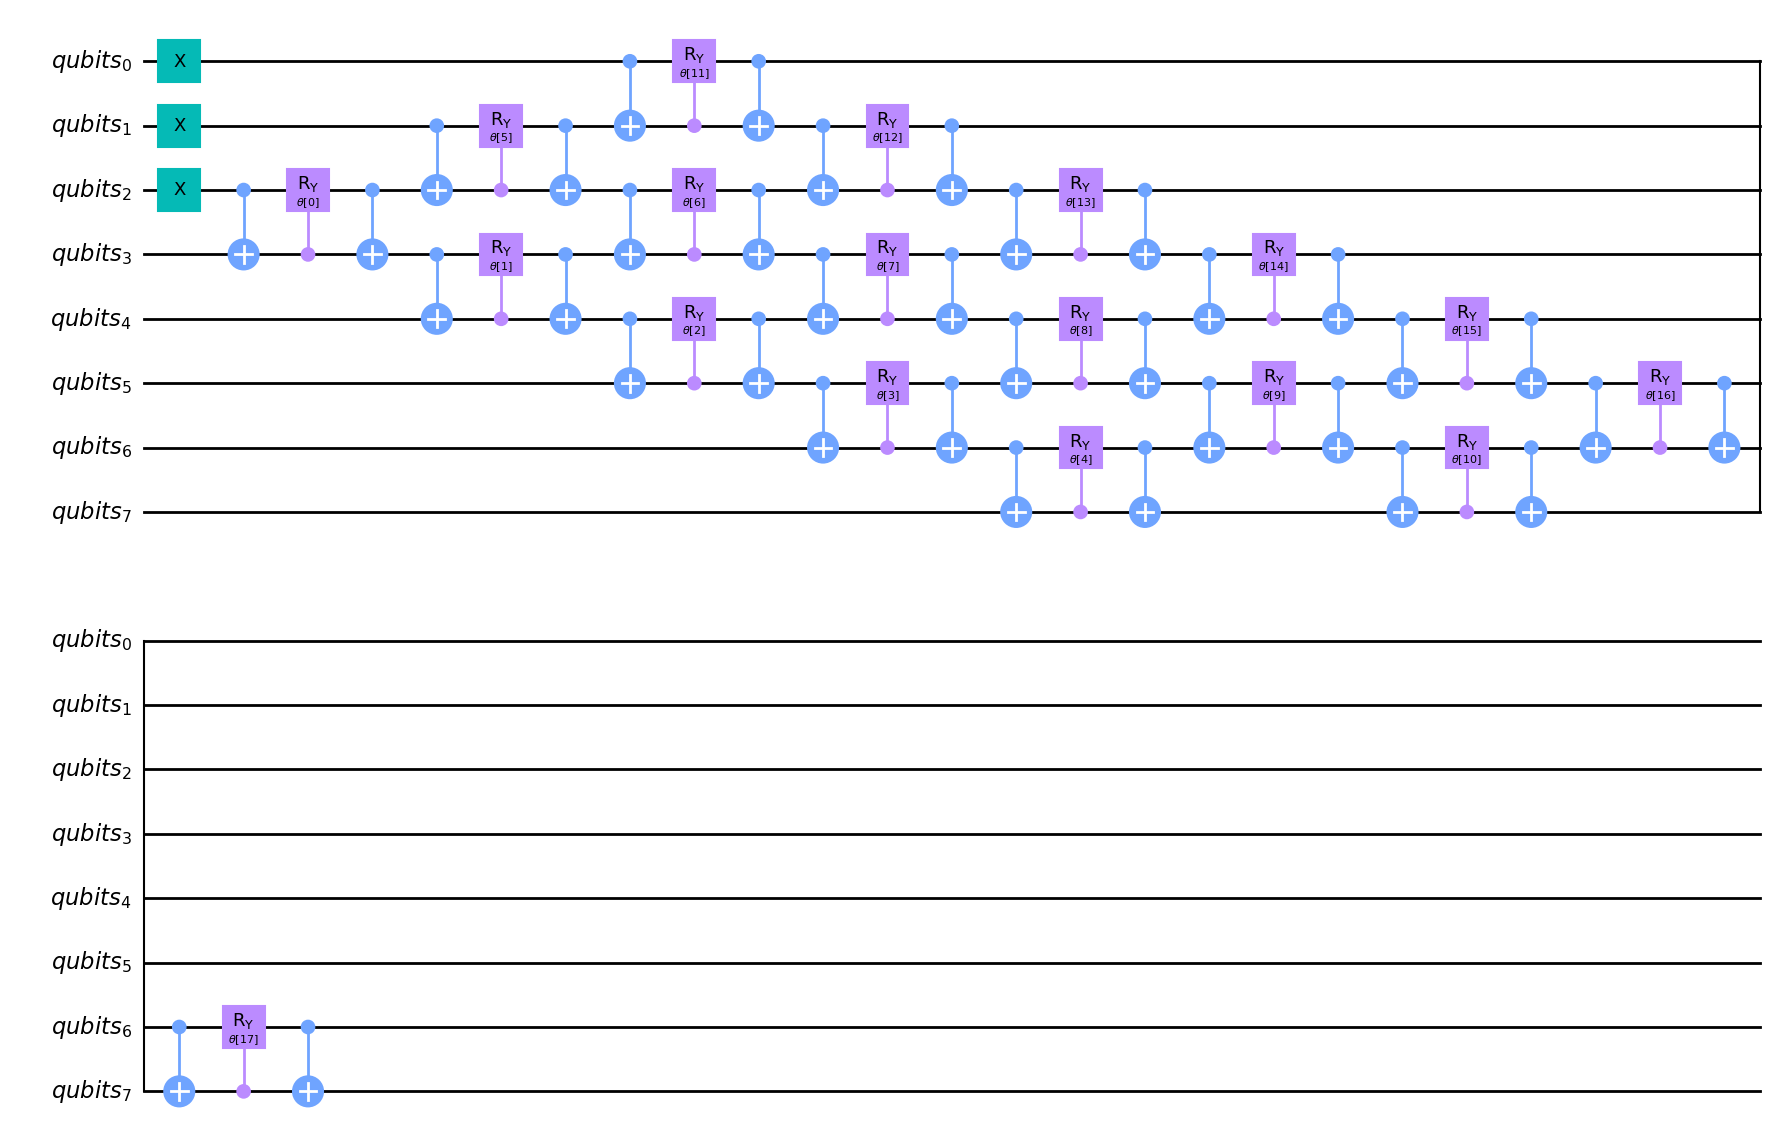

In [14]:
qc.draw(output="mpl", style="clifford")

In [15]:
def objective_scipy(x: np.ndarray) -> float:

    ansatz = qc.copy()
    params_mapper = {param: value for param, value in zip(ansatz.parameters, x)}
    ansatz = ansatz.assign_parameters(parameters=params_mapper)
    pubs = [(ansatz, ising)]
    estimator_job = estimator.run(pubs=pubs)
    estimator_result = estimator_job.result()

    obj_val = estimator_result[0].data.evs + offset

    return obj_val

In [16]:
x0 = 4*np.pi*np.random.random(size=qc.num_parameters)
result = scipy.optimize.minimize(fun=objective_scipy, x0=x0, method="cobyla")

In [17]:
result

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.8983032128341311
       x: [ 3.160e+00  1.123e+01 ...  9.810e+00  7.258e+00]
    nfev: 207
   maxcv: 0.0

In [18]:
ansatz = qc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, result.x)}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.measure_all()

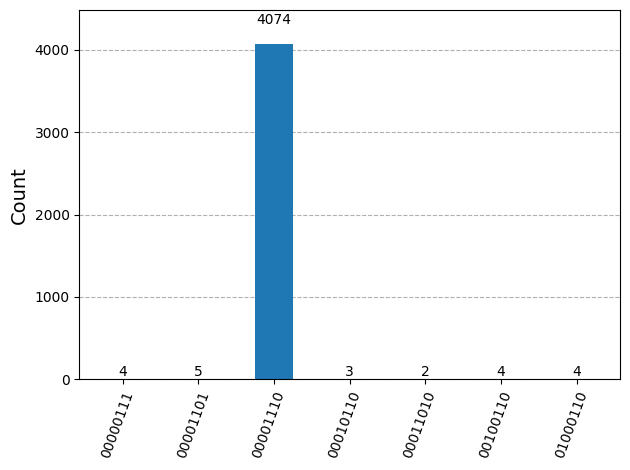

In [19]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

In [20]:
def objective_optuna(trial: Trial) -> float:

    ansatz = qc.copy()
    x = [trial.suggest_float(rf"theta[{i}]", 0, 4*np.pi) for i in range(ansatz.num_parameters)]
    params_mapper = {param: value for param, value in zip(ansatz.parameters, x)}
    ansatz = ansatz.assign_parameters(parameters=params_mapper)
    pubs = [(ansatz, ising)]
    estimator_job = estimator.run(pubs=pubs)
    estimator_result = estimator_job.result()

    obj_val = estimator_result[0].data.evs + offset

    return obj_val

In [21]:
sampler = optuna.samplers.CmaEsSampler()
study = optuna.create_study(sampler=sampler)
study.optimize(objective_optuna, n_trials=1000)

[I 2026-04-30 22:44:48,266] A new study created in memory with name: no-name-e9a6fd96-8231-4493-aab6-52bf63548444
[I 2026-04-30 22:44:48,288] Trial 0 finished with value: -0.3310915656602943 and parameters: {'theta[0]': 12.387451738375605, 'theta[1]': 0.780189033219737, 'theta[2]': 6.1492623060903675, 'theta[3]': 0.6443035158570677, 'theta[4]': 3.7978661113819214, 'theta[5]': 1.912811761151589, 'theta[6]': 8.42453652170938, 'theta[7]': 5.84975908250276, 'theta[8]': 5.504735634258145, 'theta[9]': 9.377465199028556, 'theta[10]': 0.48140735236855964, 'theta[11]': 12.115912492036689, 'theta[12]': 5.189313123966191, 'theta[13]': 11.793021288396165, 'theta[14]': 7.395939282972636, 'theta[15]': 11.644065567441238, 'theta[16]': 6.190487899610575, 'theta[17]': 9.493284448864344}. Best is trial 0 with value: -0.3310915656602943.
[I 2026-04-30 22:44:48,460] Trial 1 finished with value: -0.3648532860812244 and parameters: {'theta[0]': 5.155041569410426, 'theta[1]': 8.47758144438061, 'theta[2]': 6.

In [22]:
study.best_value

-1.0671451723397753

In [23]:
ansatz = qc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, study.best_params.values())}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.measure_all()

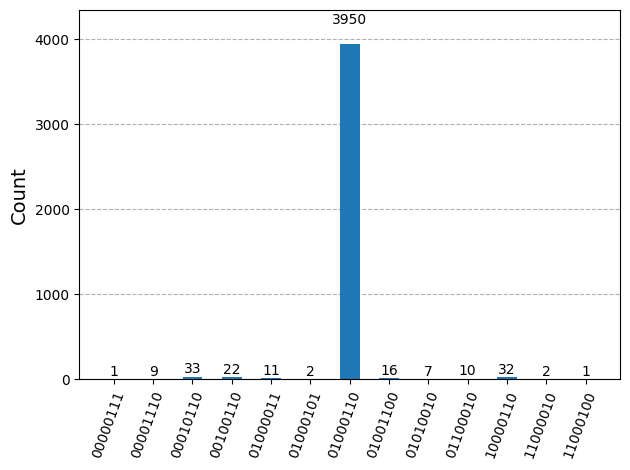

In [24]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

## Inequality constraint

In [25]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x[{i}]") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@x)+return_risk_free)
# model.add_constraint(x.sum() <= b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x[0];
dvar bool x[1];
dvar bool x[2];
dvar bool x[3];
dvar bool x[4];
dvar bool x[5];
dvar bool x[6];
dvar bool x[7];

minimize
 0.186768 x[0] - 0.575272 x[1] - 0.221385 x[2] - 0.140881 x[3] - 0.071102 x[4]
 + 0.304747 x[5] - 0.321957 x[6] + 0.003111 x[7] [ 0.000346 x[0]^2
 - 0.000019 x[0]*x[1] - 0.000032 x[0]*x[2] + 0.000058 x[0]*x[3]
 - 0.000004 x[0]*x[4] + 0.000158 x[0]*x[5] + 0.000010 x[0]*x[6]
 + 0.000171 x[0]*x[7] + 0.001042 x[1]^2 - 0.000033 x[1]*x[2]
 + 0.000227 x[1]*x[3] - 0.000075 x[1]*x[4] + 0.000588 x[1]*x[5]
 + 0.000509 x[1]*x[6] + 0.000035 x[1]*x[7] + 0.000099 x[2]^2
 - 0.000006 x[2]*x[3] + 0.000065 x[2]*x[4] - 0.000074 x[2]*x[5]
 - 0.000068 x[2]*x[6] + 0.000030 x[2]*x[7] + 0.000156 x[3]^2
 - 0.000021 x[3]*x[4] + 0.000244 x[3]*x[5] + 0.000155 x[3]*x[6]
 + 0.000120 x[3]*x[7] + 0.000091 x[4]^2 - 0.000109 x[4]*x[5]
 - 0.000096 x[4]*x[6] + 0.00001

In [26]:
quad_model = from_docplex_mp(model=model)
print(quad_model.prettyprint())

Problem name: combinatorial_portfolio_optimization

Minimize
  0.00034582882870326276*x[0]^2 - 1.9111877715248064e-05*x[0]*x[1]
  - 3.2249124001839296e-05*x[0]*x[2] + 5.807884582302285e-05*x[0]*x[3]
  - 4.275150028977837e-06*x[0]*x[4] + 0.00015848173202807187*x[0]*x[5]
  + 9.595449761210255e-06*x[0]*x[6] + 0.00017140370634917304*x[0]*x[7]
  + 0.001042228281842935*x[1]^2 - 3.338451816273136e-05*x[1]*x[2]
  + 0.00022747102040179912*x[1]*x[3] - 7.536010549264493e-05*x[1]*x[4]
  + 0.0005883460630075645*x[1]*x[5] + 0.0005093351050241277*x[1]*x[6]
  + 3.512602288772429e-05*x[1]*x[7] + 9.919768912360015e-05*x[2]^2
  - 5.9044719141154476e-06*x[2]*x[3] + 6.491443653621231e-05*x[2]*x[4]
  - 7.441457185167888e-05*x[2]*x[5] - 6.82011984593182e-05*x[2]*x[6]
  + 2.97301147811718e-05*x[2]*x[7] + 0.0001562757224020732*x[3]^2
  - 2.0673021973191743e-05*x[3]*x[4] + 0.0002444194585181468*x[3]*x[5]
  + 0.00015461870268840874*x[3]*x[6] + 0.00012008195843776206*x[3]*x[7]
  + 9.124734249834468e-05*x[4]^2 - 0

In [27]:
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
print(qubo.prettyprint())

Problem name: 

Minimize
  0.00034582882870326276*x[0]^2 - 1.9111877715248064e-05*x[0]*x[1]
  - 3.2249124001839296e-05*x[0]*x[2] + 5.807884582302285e-05*x[0]*x[3]
  - 4.275150028977837e-06*x[0]*x[4] + 0.00015848173202807187*x[0]*x[5]
  + 9.595449761210255e-06*x[0]*x[6] + 0.00017140370634917304*x[0]*x[7]
  + 0.001042228281842935*x[1]^2 - 3.338451816273136e-05*x[1]*x[2]
  + 0.00022747102040179912*x[1]*x[3] - 7.536010549264493e-05*x[1]*x[4]
  + 0.0005883460630075645*x[1]*x[5] + 0.0005093351050241277*x[1]*x[6]
  + 3.512602288772429e-05*x[1]*x[7] + 9.919768912360015e-05*x[2]^2
  - 5.9044719141154476e-06*x[2]*x[3] + 6.491443653621231e-05*x[2]*x[4]
  - 7.441457185167888e-05*x[2]*x[5] - 6.82011984593182e-05*x[2]*x[6]
  + 2.97301147811718e-05*x[2]*x[7] + 0.0001562757224020732*x[3]^2
  - 2.0673021973191743e-05*x[3]*x[4] + 0.0002444194585181468*x[3]*x[5]
  + 0.00015461870268840874*x[3]*x[6] + 0.00012008195843776206*x[3]*x[7]
  + 9.124734249834468e-05*x[4]^2 - 0.00010917755992780257*x[4]*x[5]
  - 

In [28]:
ising, offset = qubo.to_ising()

In [29]:
identity = SparsePauliOp(data="II", coeffs=[1])
ising_expanded = ising.tensor(other=identity)

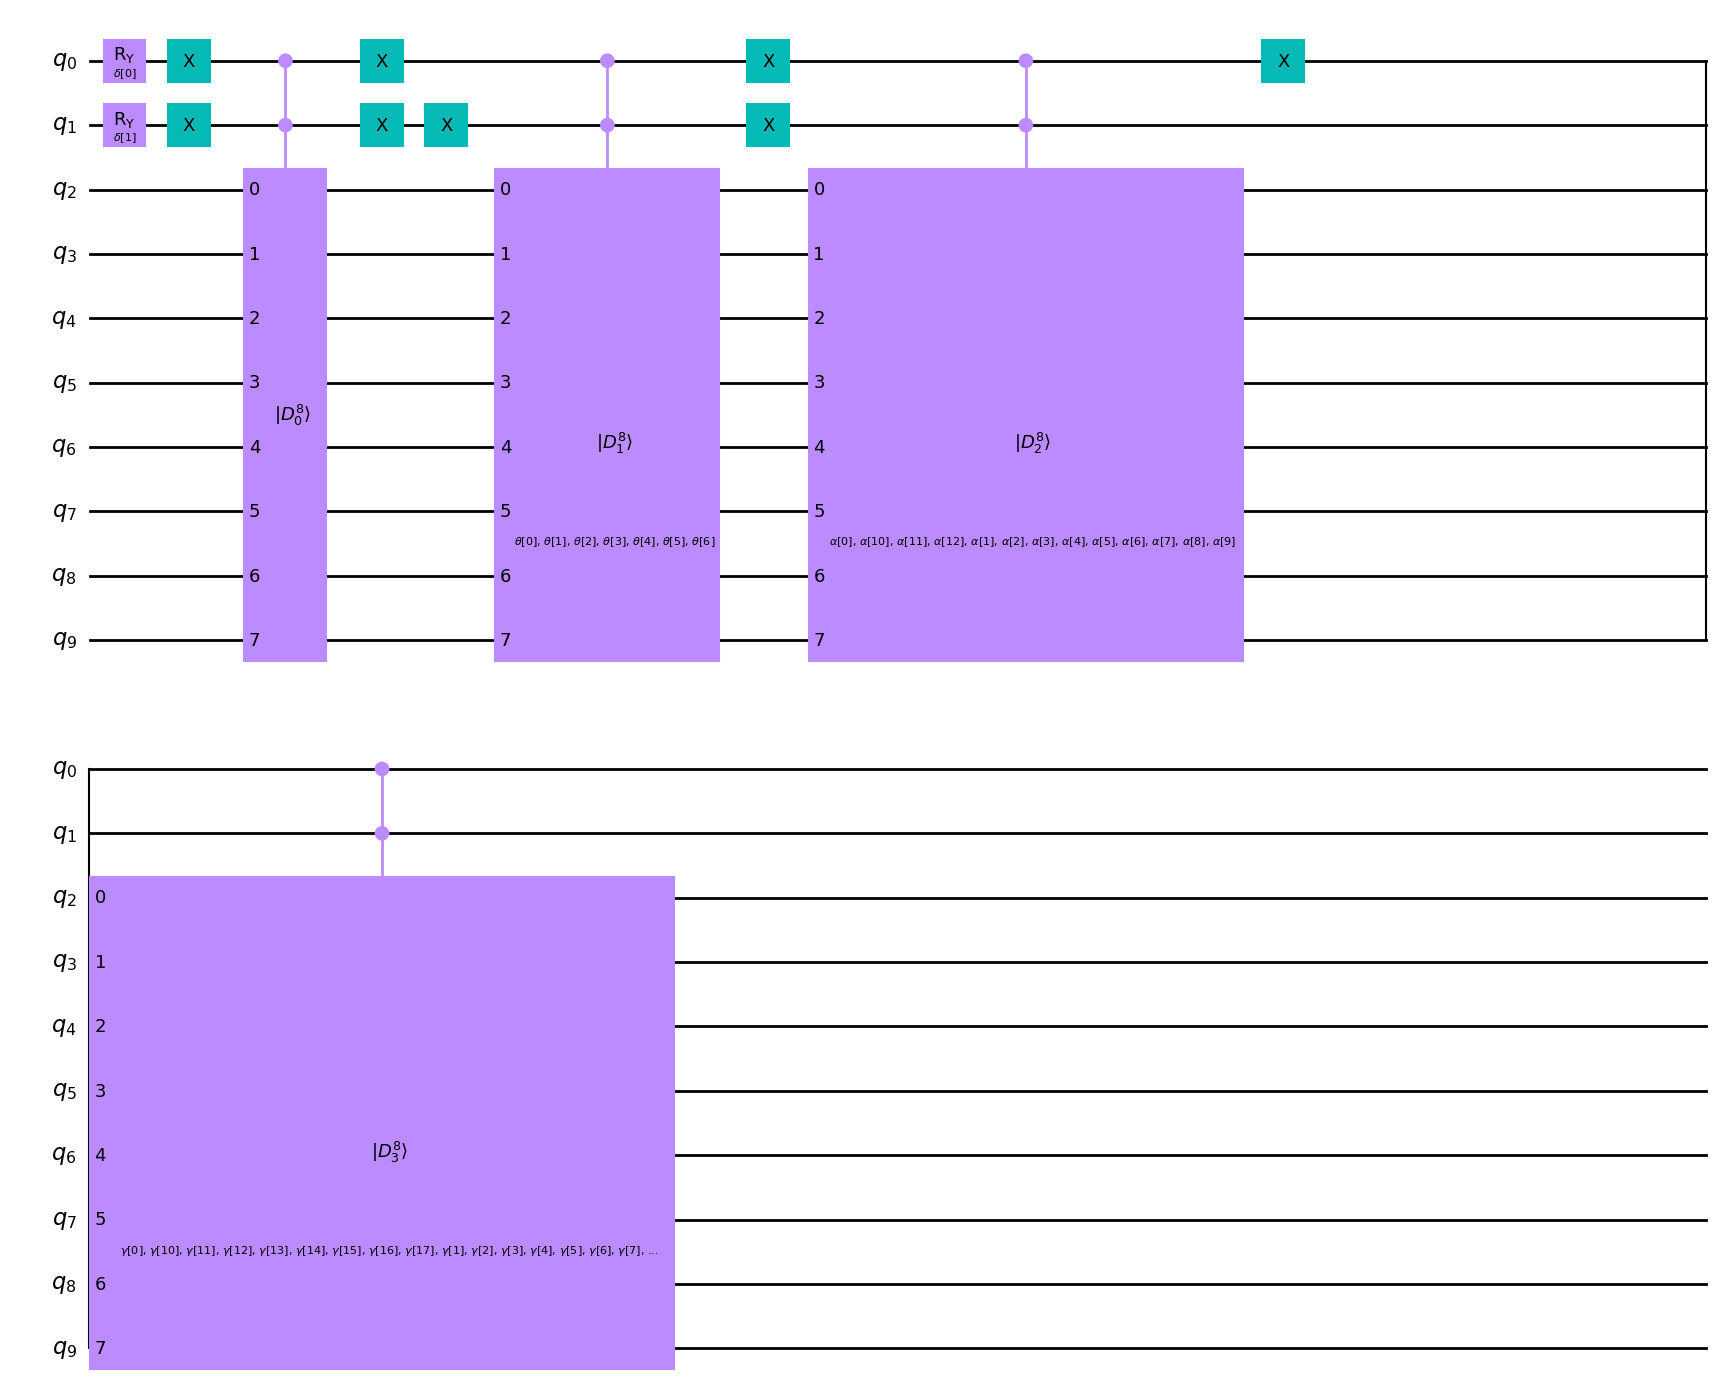

In [30]:
qubits = QuantumRegister(size=ising_expanded.num_qubits, name="q")
params_vec = ParameterVector(name=r"$\delta$", length=ising_expanded.num_qubits-ising.num_qubits)

qc = QuantumCircuit(qubits)
for idx, param in enumerate(params_vec):
    qc.ry(theta=param, qubit=qubits[idx])

params_names = {0: "", 1: "theta", 2: "alpha", 3: "gamma"}

for k in range(4):
    dicke = DickeStateAnsatz().generate_quantum_circuit(n=len(tickers), k=k, measurement=False, param_name=params_names[k])
    if k == 0:
        qc.x(qubit=qubits[[i for i in range(ising_expanded.num_qubits-ising.num_qubits)]])
    elif k == 1:
        qc.x(qubit=qubits[1])
    elif k == 2:
        qc.x(qubit=qubits[0])
    dicke_gate = dicke.to_gate(label=rf"$\vert D^{len(tickers)}_{k} \rangle$").control(2)
    qc.append(dicke_gate, qargs=range(qubits.size))
    if k == 0:
        qc.x(qubit=qubits[[i for i in range(ising_expanded.num_qubits-ising.num_qubits)]])
    elif k == 1:
        qc.x(qubit=qubits[1])
    elif k == 2:
        qc.x(qubit=qubits[0])

qc.draw(output="mpl", style="clifford")

In [31]:
def objective_scipy(x: np.ndarray) -> float:

    ansatz = tqc.copy()
    params_mapper = {param: value for param, value in zip(ansatz.parameters, x)}
    ansatz = ansatz.assign_parameters(parameters=params_mapper)
    pubs = [(ansatz, ising_expanded)]
    estimator_job = estimator.run(pubs=pubs)
    estimator_result = estimator_job.result()

    obj_val = estimator_result[0].data.evs + offset

    return obj_val

In [32]:
tqc = pm.run(qc)

In [33]:
x0 = 4*np.pi*np.random.random(size=qc.num_parameters)
result = scipy.optimize.minimize(fun=objective_scipy, x0=x0, method="cobyla")

In [34]:
result

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.0523652020431506
       x: [ 3.023e+00  1.264e+01 ...  6.293e+00  1.140e+01]
    nfev: 404
   maxcv: 0.0

In [35]:
bits = ClassicalRegister(size=ising.num_qubits)
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, result.x)}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.add_register(bits)
ansatz.measure(qubit=ansatz.qregs[0][ising_expanded.num_qubits-ising.num_qubits:], cbit=bits)

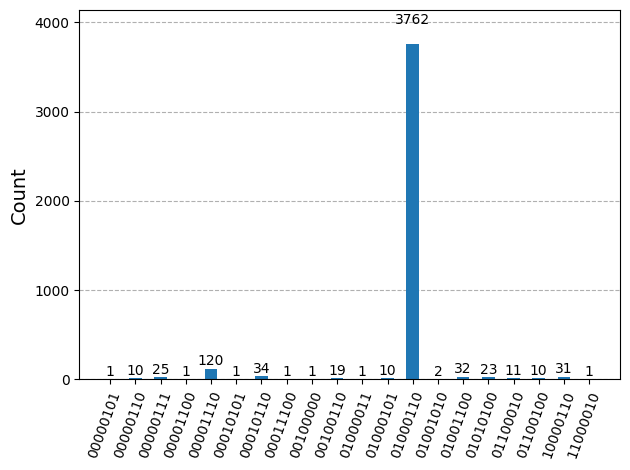

In [36]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

In [37]:
def objective_optuna(trial: Trial) -> float:

    ansatz = tqc.copy()
    x = [trial.suggest_float(f"param[{i}]", 0, 4*np.pi) for i in range(ansatz.num_parameters)]
    params_mapper = {param: value for param, value in zip(ansatz.parameters, x)}
    ansatz = ansatz.assign_parameters(parameters=params_mapper)
    pubs = [(ansatz, ising_expanded)]
    estimator_job = estimator.run(pubs=pubs)
    estimator_result = estimator_job.result()

    obj_val = estimator_result[0].data.evs + offset

    return obj_val

In [38]:
sampler = optuna.samplers.CmaEsSampler()
study = optuna.create_study(sampler=sampler)
study.optimize(objective_optuna, n_trials=1000)

[I 2026-04-30 22:45:46,569] A new study created in memory with name: no-name-cb266ffc-85e8-4acd-9087-598012200887
[I 2026-04-30 22:45:46,602] Trial 0 finished with value: -0.1759579687681275 and parameters: {'param[0]': 9.634064051677589, 'param[1]': 9.837664201019315, 'param[2]': 9.121990996177745, 'param[3]': 0.9797513108357986, 'param[4]': 6.554318484097408, 'param[5]': 6.0550828808439805, 'param[6]': 6.03951148067092, 'param[7]': 0.3009828996771162, 'param[8]': 10.002938048988996, 'param[9]': 0.01721401184853015, 'param[10]': 0.1745033781763588, 'param[11]': 12.263612429485416, 'param[12]': 1.5717902965528523, 'param[13]': 3.7228091125866833, 'param[14]': 10.86125795617604, 'param[15]': 10.015937515007463, 'param[16]': 7.401273548148994, 'param[17]': 10.471176162174446, 'param[18]': 10.36184108931038, 'param[19]': 9.768950713789462, 'param[20]': 5.923037857423179, 'param[21]': 3.525935844343653, 'param[22]': 8.734025352312273, 'param[23]': 7.55305844993585, 'param[24]': 9.313880120

In [39]:
study.best_value

-0.8429759687313876

In [40]:
bits = ClassicalRegister(size=ising.num_qubits)
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, study.best_params.values())}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.add_register(bits)
ansatz.measure(qubit=ansatz.qregs[0][ising_expanded.num_qubits-ising.num_qubits:], cbit=bits)

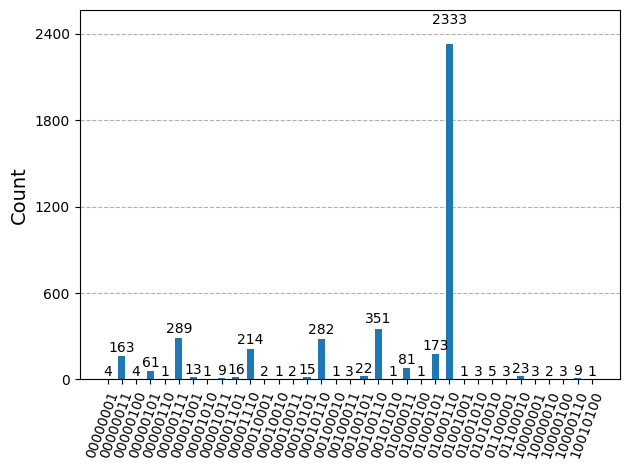

In [41]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)